In [31]:
import csv
import numpy as np
import math
import pandas as pd

# IMPLEMENT KNN

In [32]:
file = open("./dataset/Iris.csv", "r")
dataset = csv.reader(file)
dataset = np.array(list(dataset))
dataset = np.delete(dataset, 0, 0) # delete first row
dataset = np.delete(dataset, 0, 1) # delete first col
dataset
file.close()

training_dataset = dataset[ :149]
testing_dataset = dataset[149: ]

## FROM SCRATCH

In [33]:
def compute_distance(point1, point2):
    result = 0
    for i in range(4):
        result += (float(point1[i]) - float(point2[i])) ** 2
    return math.sqrt(result)

def compute_KnearestNeightbor(training_dataset, item, k):
    distances = []
    for dataPoint in training_dataset:
        distances.append({"label": dataPoint[-1],
                         "value": compute_distance(item, dataPoint)
                         })
    distances.sort(key=lambda x: x["value"])
    labels = [item["label"] for item in distances]
    return labels[:k]
    
def voteTheDistance(array):
    labels = set(array)
    result = ""
    maxOccur = 0
    for label in labels:
        num = array.count(label)
        if num > maxOccur:
            maxOccur = num
            result = label
    return result

In [34]:
k = 5
for item in testing_dataset:
    knn = compute_KnearestNeightbor(training_dataset, item, k)
    result = voteTheDistance(knn)
    print(f"GT = {item[-1]}, Predict = {result}")

GT = Iris-virginica, Predict = Iris-virginica


HOW TO SELECT K IN KNN

In [35]:
dataset = pd.read_csv("./dataset/Iris.csv")
dataset = dataset.drop(columns=["Id"])
dataset = dataset.rename(columns={"SepalLengthCm": "Sepal-length", 
                                  "SepalWidthCm": "Sepal-width", 
                                  "PetalLengthCm": "Petal-length", 
                                  "PetalWidthCm": "Petal-width",
                                  "Species": "Class"})
dataset

,Sepal-length,Sepal-width,Petal-length,Petal-width,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [36]:
x_data = dataset.iloc[:, :-1].values
y_data = dataset.iloc[:, -1].values

In [37]:
print(x_data)
print(y_data)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.1 1.5 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

## USING LIBRARY

In [38]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=1)

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)

x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [40]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [41]:
y_pred = classifier.predict(x_test)

y_pred != y_test
count = 0
for i in range(len(y_pred)):
    if y_pred[i] != y_test[i]:
        print(f"item = {i}, GT = {y_test[i]}, Predict = {y_pred[i]}")
        count += 1

print(count)

item = 22, GT = Iris-versicolor, Predict = Iris-virginica
1


In [42]:
from sklearn.metrics import classification_report, accuracy_score
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.86      1.00      0.92         6

       accuracy                           0.97        30
      macro avg       0.95      0.97      0.96        30
   weighted avg       0.97      0.97      0.97        30



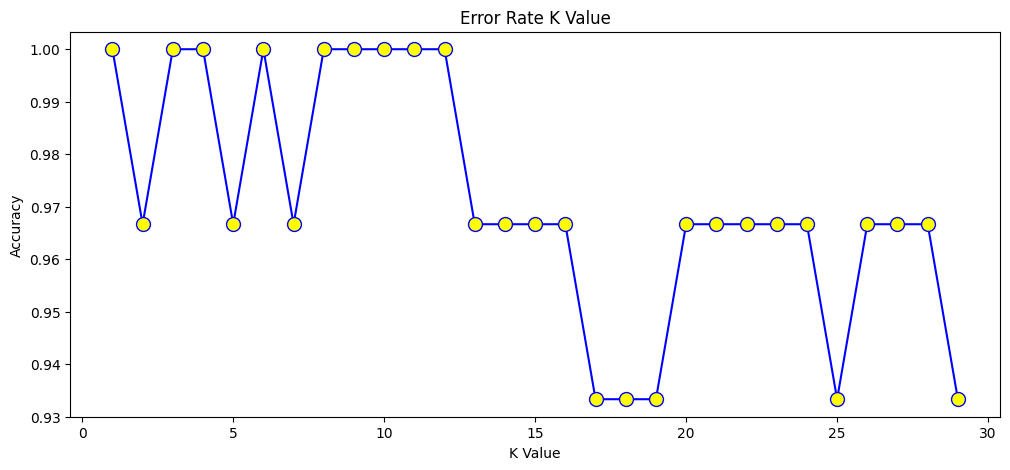

In [43]:
import matplotlib.pyplot as plt
error = []

# Calculate accuracy for K-value between 1 and 30
for i in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    pred_i = knn.predict(x_test)
    error.append(accuracy_score(pred_i, y_test))

plt.figure(figsize=(12, 5))
plt.plot(range(1, 30), error, color="blue", marker="o", markerfacecolor="yellow",markersize=10)
plt.title("Error Rate K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.show()

PROBLEM WITH K ODD AND EVEN

In [ ]:
#Required Libraries
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

In [45]:
penguin = pd.read_csv("./dataset/penguins.csv")
penguin.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,MALE
1,Adelie,Torgersen,39.5,17.4,186,3800,FEMALE
2,Adelie,Torgersen,40.3,18.0,195,3250,FEMALE
3,Adelie,Torgersen,36.7,19.3,193,3450,FEMALE
4,Adelie,Torgersen,39.3,20.6,190,3650,MALE


In [54]:
x = penguin[['culmen_length_mm','culmen_depth_mm','flipper_length_mm','body_mass_g']]
y = penguin[['species']]

In [55]:
np.random.seed(0)
X_train, X_test, y_train, y_test = train_test_split(x, y,test_size = 0.2, stratify = y,random_state = 4)

In [57]:
X_test = np.array(X_test)
X_train = np.array(X_train)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [62]:
def knn_modified(x_train, y_train, x_test, k):
    pred = []
    # Loop through each test point
    for j in range(len(x_test)):
        distance = []
        # Calculate distance to all training points
        for i in range(len(x_train)):
            euclidean_distance = np.sqrt(np.sum(np.square(x_test[j,] - x_train[i,])))
            # Store both distance and index i
            distance.append((euclidean_distance, i))
            
        # Sort by distance (first element of tuple)
        distance.sort()
        
        # Get indices of k nearest neighbors
        neighbours = []
        for i in range(k):
            neighbours.append(distance[i][1]) # Now valid: accessing index from tuple

        # Get labels of k nearest neighbors
        target = []
        for l in range(k):
            # Assuming y_train[index] returns an array/list where 0-th element is label
            # This matches original code structure: np.array(y_train)[neighbours[l]][0]
            target.append(np.array(y_train)[neighbours[l]][0])
        
        # Count votes
        count = {}
        for t in target:
            count[t] = count.get(t, 0) + 1

        # Create list of (count, label) tuples
        pairs = []
        for key in count:
            pairs.append((count[key], key))

        # Sort by count descending
        pairs.sort(reverse=True)
        
        # Handle ties / even k logic from original code
        if k % 2 == 0:
            even = []
            # Find all labels with max votes (check for ties)
            for i in range(len(pairs)):
                if pairs[0][0] == pairs[i][0]:
                    even.append(pairs[i][1])
            
            # If tie, check nearest neighbor logic
            # Use original loop variable name 'n_idx' to avoid confusion with outer loop
            match_found = False
            for n_idx in neighbours:
                label = np.array(y_train)[n_idx][0]
                if label in even:
                    pred.append(label)
                    # print("value with the least distance classification: ", label)
                    match_found = True
                    break
            
            if not match_found:
                # Fallback to most frequent if logic fails (shouldn't if handled correctly)
                pred.append(pairs[0][1])
        else:
            # Odd k, just take majority vote
            pred.append(pairs[0][1])
            
    return pred

In [63]:
n = 2
pred = knn_modified(X_train,y_train,X_test,k=n)
neighbors = list(range(1,11))
scores = []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k,algorithm='brute', metric='euclidean')
    pred1 = knn.fit(X_train, y_train)
    pred = pred1.predict(X_test)
    accuracy =  accuracy_score(y_test, pred)
    scores.append(accuracy)

scores1 = []
neighbors = list(range(1,11))
for i in neighbors:
    pred = knn_modified(X_train,y_train,X_test,k=i)
    accuracy =  accuracy_score(y_test, pred)
    scores1.append(accuracy)

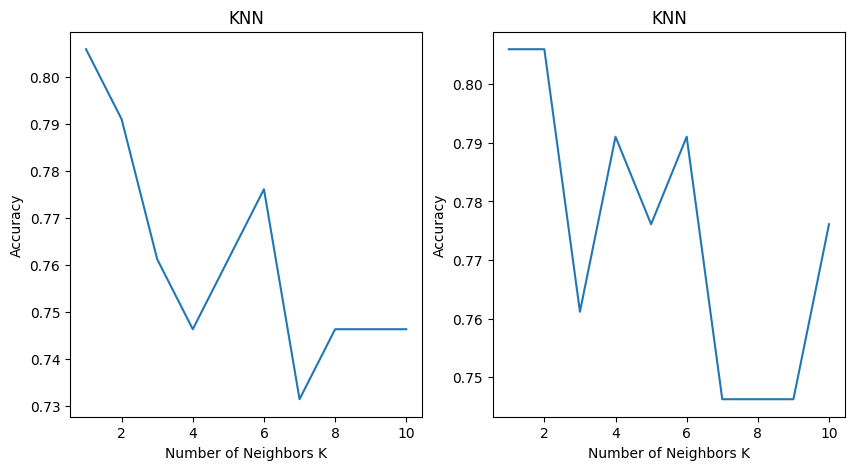

In [64]:
MSE = [ x for x in scores]
plt.figure(figsize=(10, 5))
MSE1 = [ x for x in scores1]
plt.subplot(1,2,1)
plt.plot(neighbors, MSE)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Accuracy')
plt.title('KNN')
plt.subplot(1,2,2)
plt.plot(neighbors, MSE1)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Accuracy')
plt.title('KNN')
plt.show()

In [50]:
from sklearn import datasets

dataset = datasets.load_iris()
x = dataset.data
y = dataset.target

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.5)

In [51]:
classifier = KNeighborsClassifier(n_neighbors=8, weights = 'uniform', p = 2)
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)

print("accuracy %.2f%%"%(100*accuracy_score(y_test,y_pred)))
print(classification_report(y_test,y_pred))

accuracy 94.67%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       0.91      0.97      0.94        30
           2       0.95      0.88      0.91        24

    accuracy                           0.95        75
   macro avg       0.95      0.95      0.95        75
weighted avg       0.95      0.95      0.95        75



In [52]:
classifier = KNeighborsClassifier(n_neighbors=8, p = 2, weights="distance")
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)

print("accuracy %.2f%%"%(100*accuracy_score(y_test,y_pred)))
print(classification_report(y_test,y_pred))

accuracy 96.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       0.94      0.97      0.95        30
           2       0.96      0.92      0.94        24

    accuracy                           0.96        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.96      0.96      0.96        75



In [53]:
def customizeWeight(distances):
  sigma = 0.5
  return np.exp(-distances**2/sigma)

classifier = KNeighborsClassifier(n_neighbors=4, p = 2, weights=customizeWeight)
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)

print("accuracy %.2f%%"%(100*accuracy_score(y_test,y_pred)))
print(classification_report(y_test,y_pred))

accuracy 93.33%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       0.88      0.97      0.92        30
           2       0.95      0.83      0.89        24

    accuracy                           0.93        75
   macro avg       0.94      0.93      0.94        75
weighted avg       0.94      0.93      0.93        75

